In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets.values.ravel()

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# split train/test data by 85/15
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=6)

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# preprocessor (column transformer)
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), numerical_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# pipeline
pipe = Pipeline([
    ('prep', preprocessor),
    ('gbc', GradientBoostingClassifier(random_state=6))
])

# hyperparameter searching over 40 intervals with 5-fold cross validation
param_dist = {
    "gbc__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "gbc__n_estimators": [100, 200, 300, 500],
    "gbc__subsample": [0.6, 0.8, 1.0],
    "gbc__min_samples_leaf": [1, 3, 5, 10],
    "gbc__max_depth": [2, 3, 4, 5],
    "gbc__max_features": [None, "sqrt", "log2"]
}
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="accuracy",
    random_state=6,
    n_jobs=-1
)
search.fit(X_train, y_train)
gb_clf = search.best_estimator_

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# wrap trained GB classifier in calibrator
calibrator = CalibratedClassifierCV(estimator=gb_clf, method='sigmoid', cv=5)
calibrator.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('prep',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    RobustScaler())]),
                                                                                   ['age',
                                                                                    'trestbps',
                                                                                    'chol',
                                                                                    'thalach',
                                                                                    'oldpeak',
                                                                                    'ca']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                   ('encoder',
                                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                                   ['sex',
                                                                                    'cp',
                                                                                    'fbs',
                                                                                    'restecg',
                                                                                    'exang',
                                                                                    'slope',
                                                                                    'thal'])])),
                                                 ('gbc',
                                                  GradientBoostingClassifier(learning_rate=0.01,
                                                                             max_depth=4,
                                                                             max_features='log2',
                                                                             min_samples_leaf=3,
                                                                             n_estimators=200,
                                                                             random_state=6))]))

Accuracy: 0.587

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.96      0.84        25
           1       0.00      0.00      0.00         8
           2       0.67      0.33      0.44         6
           3       0.12      0.20      0.15         5
           4       0.00      0.00      0.00         2

    accuracy                           0.59        46
   macro avg       0.31      0.30      0.29        46
weighted avg       0.51      0.59      0.53        46

Macro-averaged harmonic mean: 0.288
Quadratic Weighted Kappa: 0.628


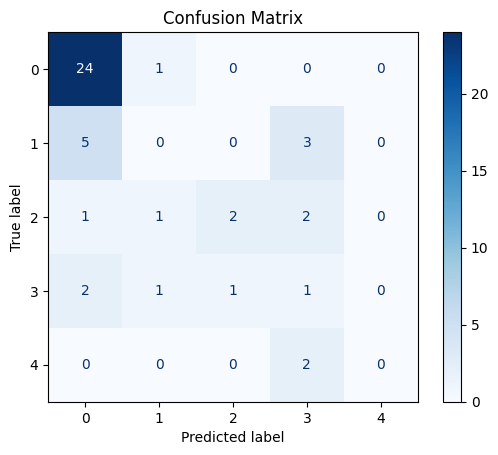

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
import matplotlib.pyplot as plt

# Test Model
y_pred = calibrator.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=[str(c) for c in gb_clf.classes_], zero_division=0)
print("\nClassification Report:\n", class_report)

# Macro-averaged Harmonic Mean
macro_avg = f1_score(y_test, y_pred, average='macro')
print(f'Macro-averaged harmonic mean: {macro_avg:.3f}')

# Quadratic Weighted Kappa Score
kappa = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f'Quadratic Weighted Kappa: {kappa:.3f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(cm, display_labels=gb_clf.classes_)
display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

    true_label  pred_label  max_proba   entropy
25           3           1   0.279878  1.550150
28           0           1   0.276654  1.524810
9            2           2   0.281827  1.524103
10           1           0   0.280984  1.497819
30           3           2   0.310518  1.487521
3            3           0   0.373465  1.486424
16           2           1   0.357409  1.480582
45           2           0   0.356753  1.478464
29           3           0   0.378375  1.468382
39           4           3   0.368952  1.468193


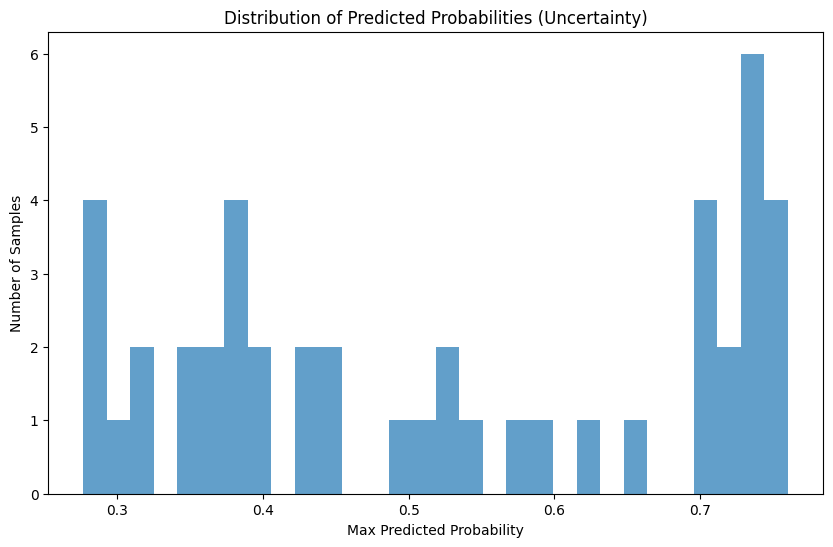

In [ ]:
# obtain calibrated probabilities
y_prob_cal = calibrator.predict_proba(X_test)

# calculate uncertainty as entropy
entropy = -np.sum(y_prob_cal * np.log(y_prob_cal + 1e-12), axis=1)

# create dataframe to inspect most uncertain predictions
uncertain = pd.DataFrame({
    "true_label": y_test,
    "pred_label": y_pred,
    "max_proba": y_prob_cal.max(axis=1),
    "entropy": entropy
})

# sort by highest uncertainty / entropy
uncertain = uncertain.sort_values(by="entropy", ascending=False)

# show top 10 most uncertain
print(uncertain.head(10))

plt.figure(figsize=(10,6))
plt.hist(uncertain['max_proba'], bins=30, alpha=0.7)
plt.xlabel("Max Predicted Probability")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predicted Probabilities (Uncertainty)")
plt.show()

<Figure size 1000x1000 with 0 Axes>

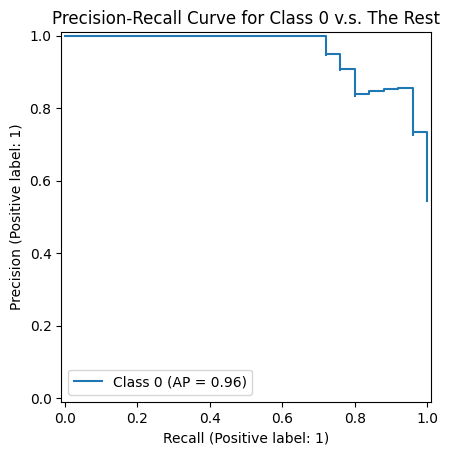

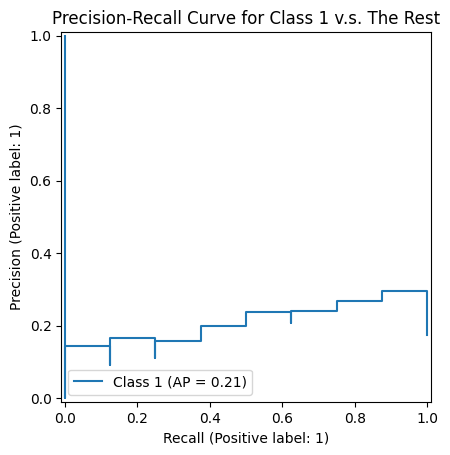

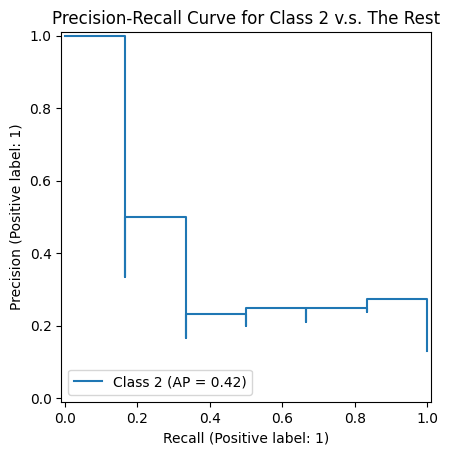

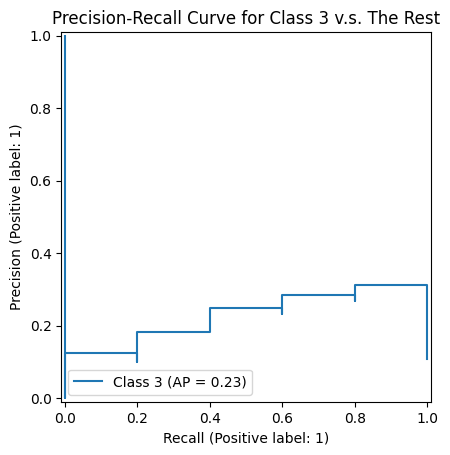

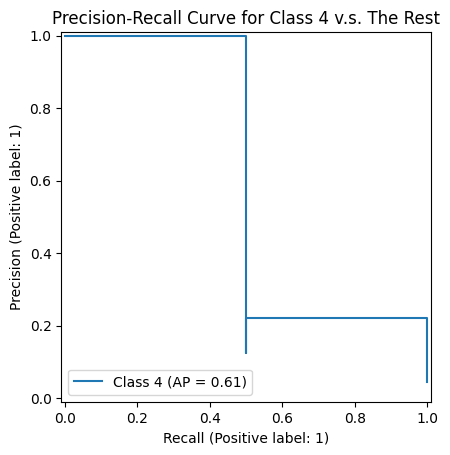

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

# Precision Recall Curves
plt.figure(figsize=(10, 10))

classes = calibrator.classes_
for i, c in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(
        (y_test == c).astype(int),
        y_prob_cal[:, i],
        name=f'Class {c}'
    )
    plt.title(f'Precision-Recall Curve for Class {c} v.s. The Rest')

plt.show()

     feature  importance       std
4       chol    0.032609  0.013460
11        ca    0.031159  0.017467
7    thalach    0.012319  0.027887
10     slope    0.011594  0.021545
2         cp    0.006522  0.033748
9    oldpeak    0.005072  0.022927
5        fbs    0.005072  0.009195
1        sex    0.005072  0.009195
0        age    0.003623  0.022510
6    restecg    0.002899  0.014565
3   trestbps    0.001449  0.016777
8      exang   -0.002174  0.018058
12      thal   -0.008696  0.026087


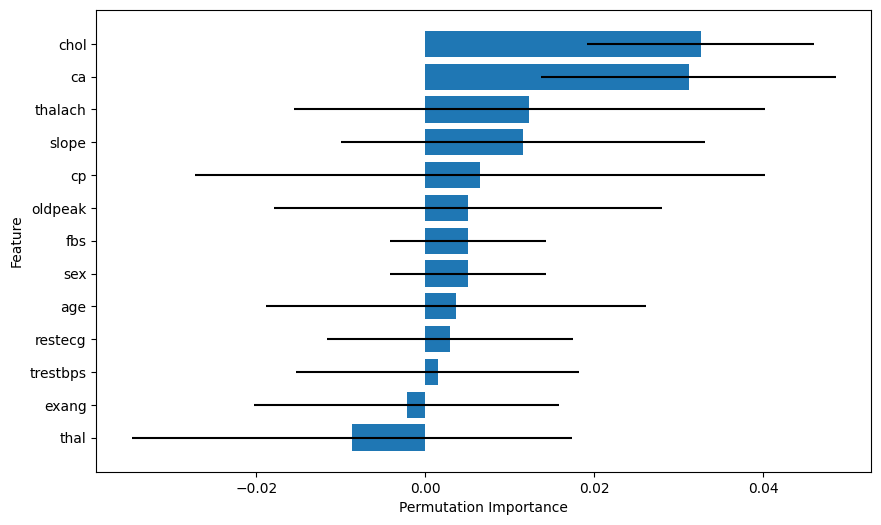

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Permutation Feature Importance
importances = permutation_importance(calibrator, X_test, y_test, n_repeats=30, random_state=6, scoring='accuracy')
importances_mean = importances.importances_mean
stds = importances.importances_std

feature_names = X_test.columns

assert len(feature_names) == len(importances_mean), "feature mismatch"

feat_im = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_mean,
    "std": stds
}).sort_values(by="importance", ascending=False)

print(feat_im)

plt.figure(figsize=(10,6))
plt.barh(feat_im['feature'], feat_im['importance'], xerr=feat_im['std'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

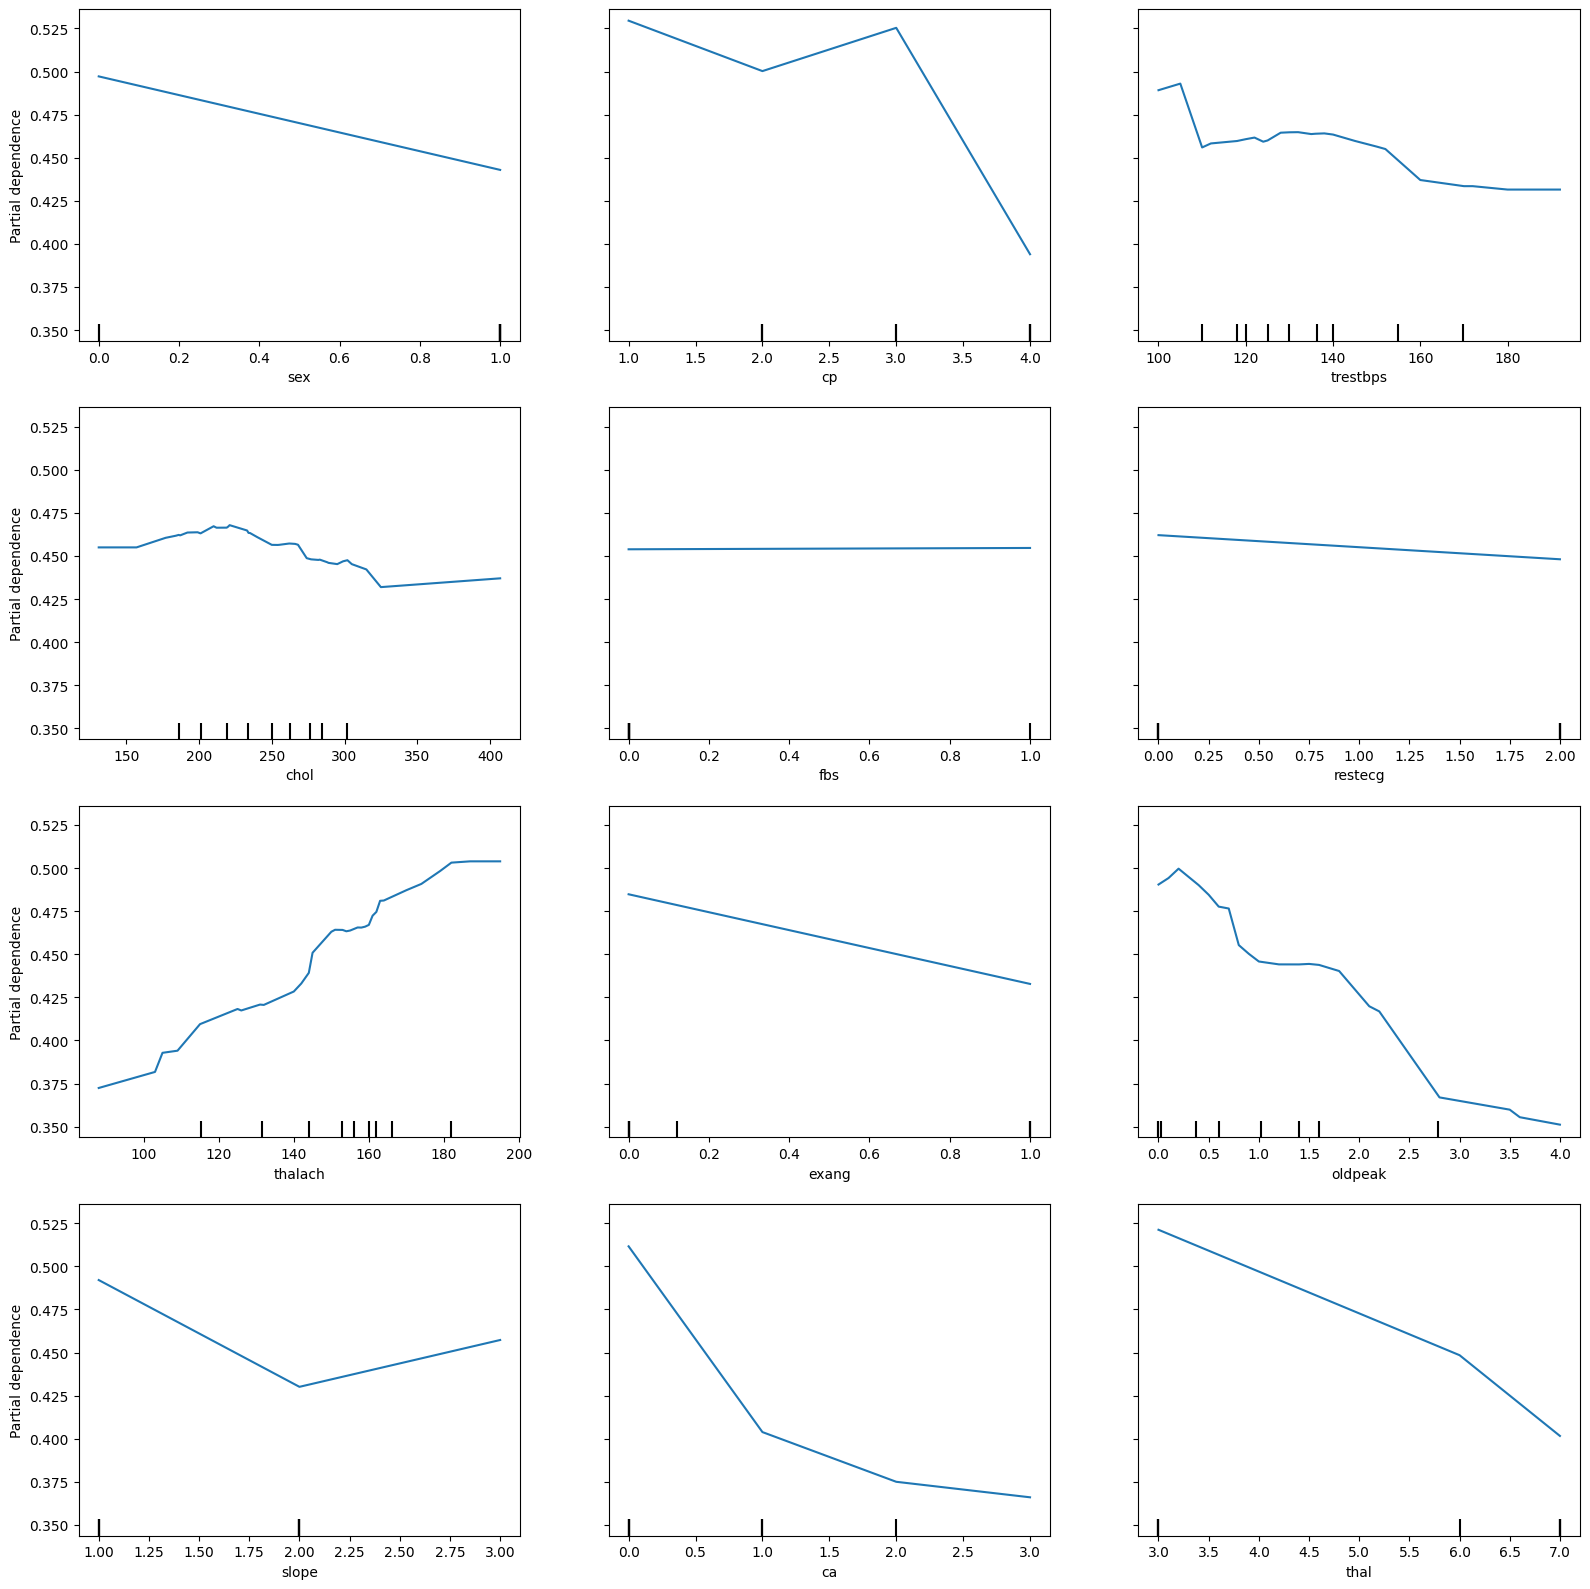

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features = ['sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 0

# Partial Dependence Plots
fig, ax = plt.subplots(figsize=(16, 16))
PartialDependenceDisplay.from_estimator(
    calibrator,
    X_test,
    features=features,
    target=target,
    kind='average',
    grid_resolution=50,
    ax=ax
)
plt.tight_layout()
plt.show()